In [1]:
# Wczytanie bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Ustawienie żeby zawsze wyświetlały się wszystkie kolumny
pd.set_option('display.max_columns', None)

# Ustawienie estetyki wykresów
sns.set_theme(style='whitegrid')        # włączamy linie szarej siatki w tle
plt.rcParams["figure.figsize"] = (10,6) # ustawiamy wielkość każdego z wykresów

In [21]:
# Wczytanie danych
data = pd.read_csv("german_credit_data.csv")

# Sprawdzenie wymiarów datasetu
print(f"Zbiór ma {data.shape[0]} wierszy i {data.shape[1]} kolumn.\n") # Formatted String Literal

# Nazwy kolumn
print(data.columns)

Zbiór ma 1000 wierszy i 21 kolumn.

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')


In [26]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [68]:
data.isnull().sum()

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

### Tylko zmienne numeryczne

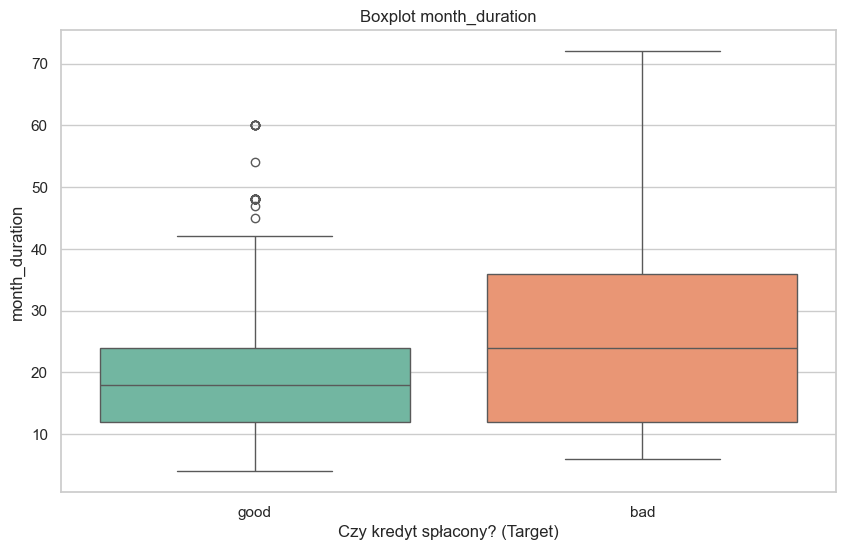

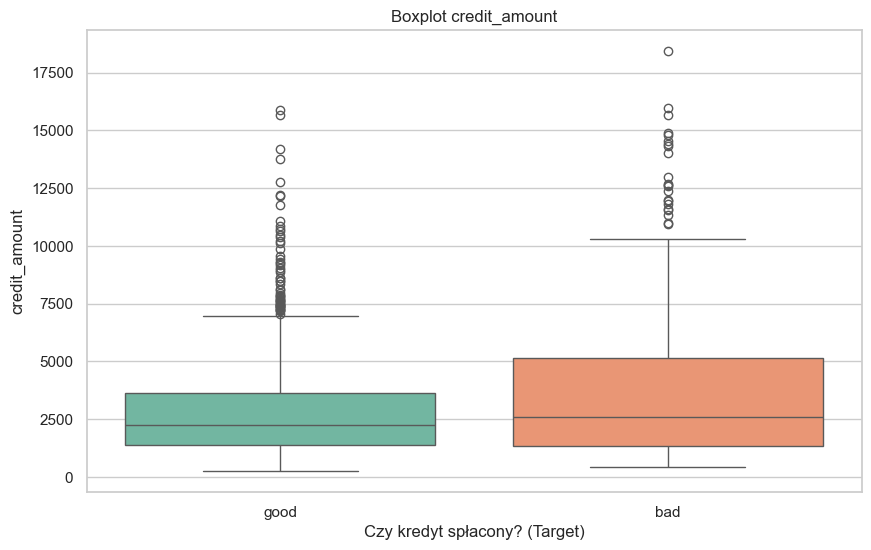

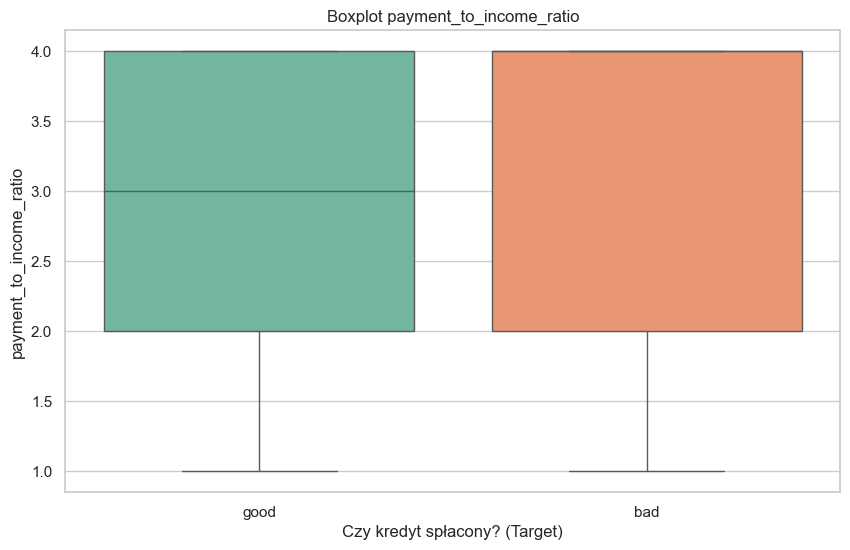

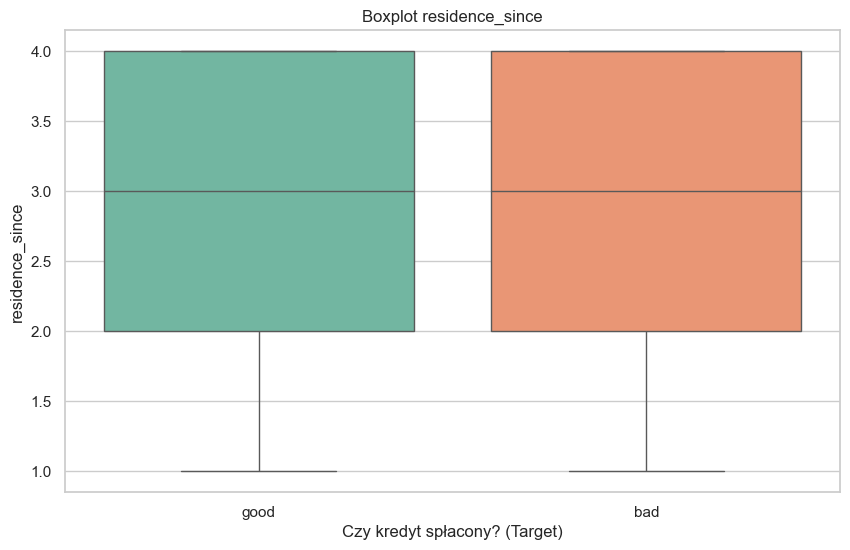

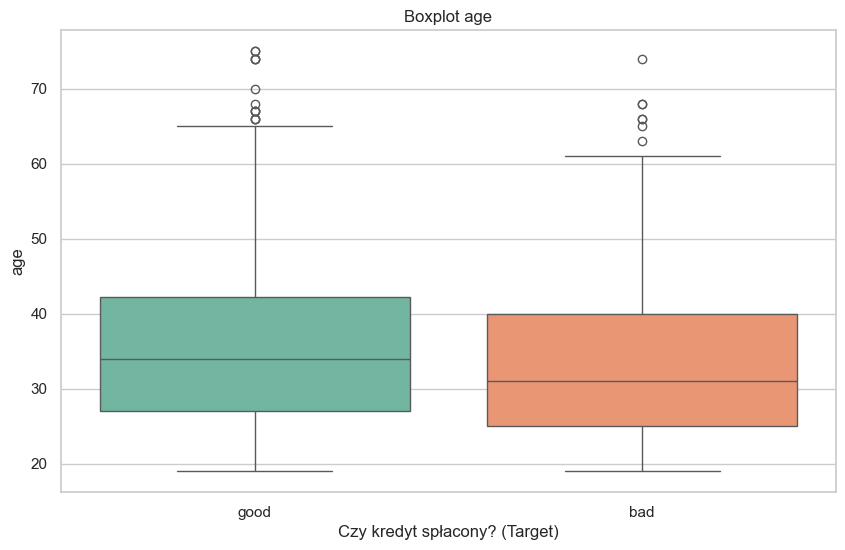

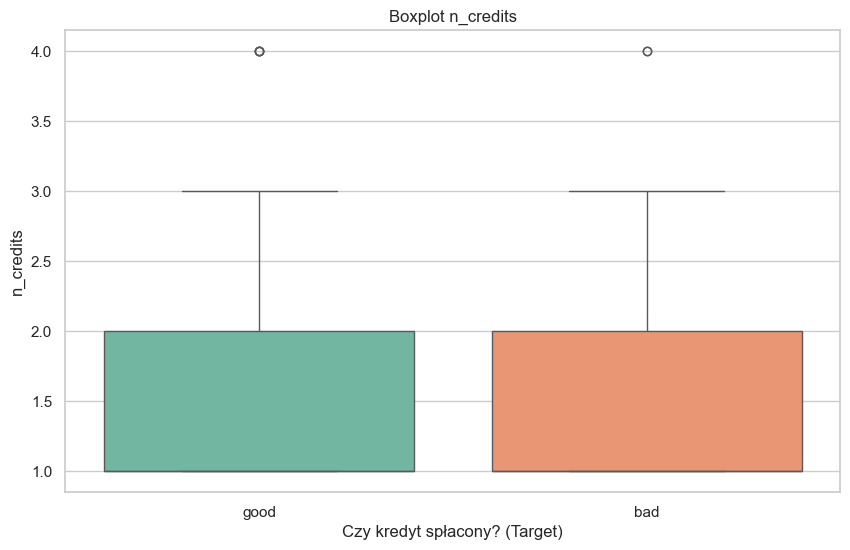

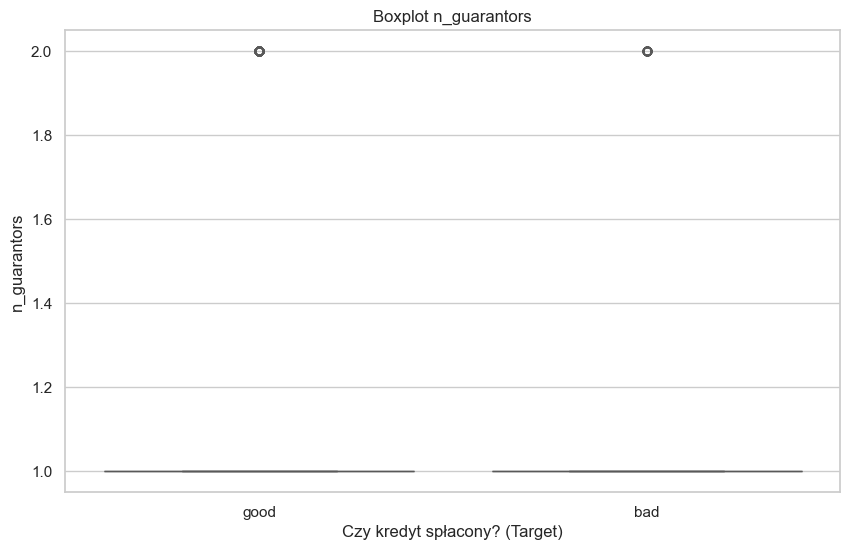

In [36]:
# Tylko zmienne numeryczne
num_cols = data.select_dtypes(['int64', 'float64']).columns

# Pętla, która dla każdej zmiennej rysuje boxplot
for col in num_cols:
    sns.boxplot(data=data, x='target', y=col, palette='Set2', hue='target', legend=False)
    plt.title(f'Boxplot {col}')
    plt.xlabel('Czy kredyt spłacony? (Target)')
    plt.ylabel(f'{col}')
    plt.show()

Wykres pudełkowy *n_guarantors* nie ma sensu bo większość klientów miała tylko jednego poręczyciela - stąd wykres jako kreska na samym dole. Kropki na górze to przypadki osób, które miały 2 poręczycieli - boxplot szanuje ich jako outliery. 
  
  Dlatego zrobiłam poniżej countplot.

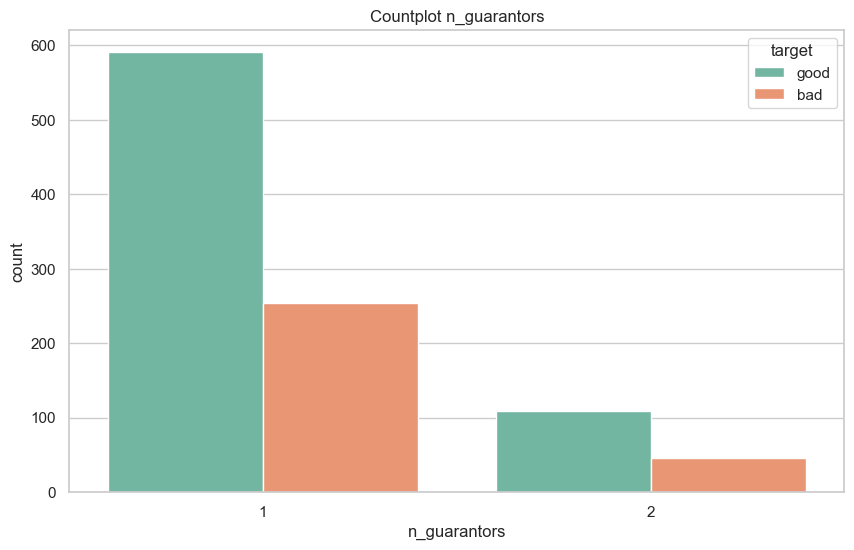

In [49]:
sns.countplot(data=data, x='n_guarantors', legend=True, hue='target', palette='Set2')
plt.title('Countplot n_guarantors')
plt.show();

### Tylko zmienne tekstowe (object)

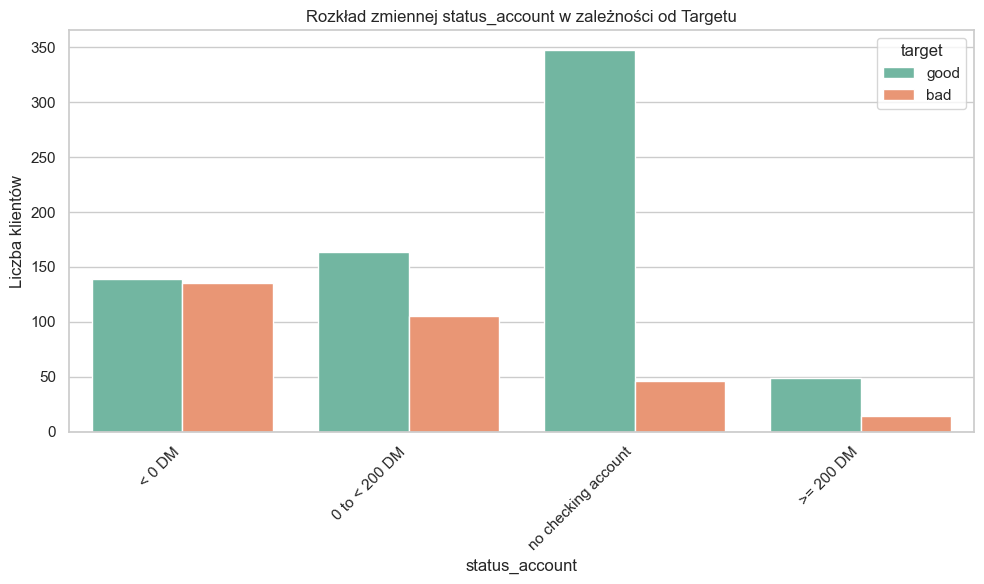

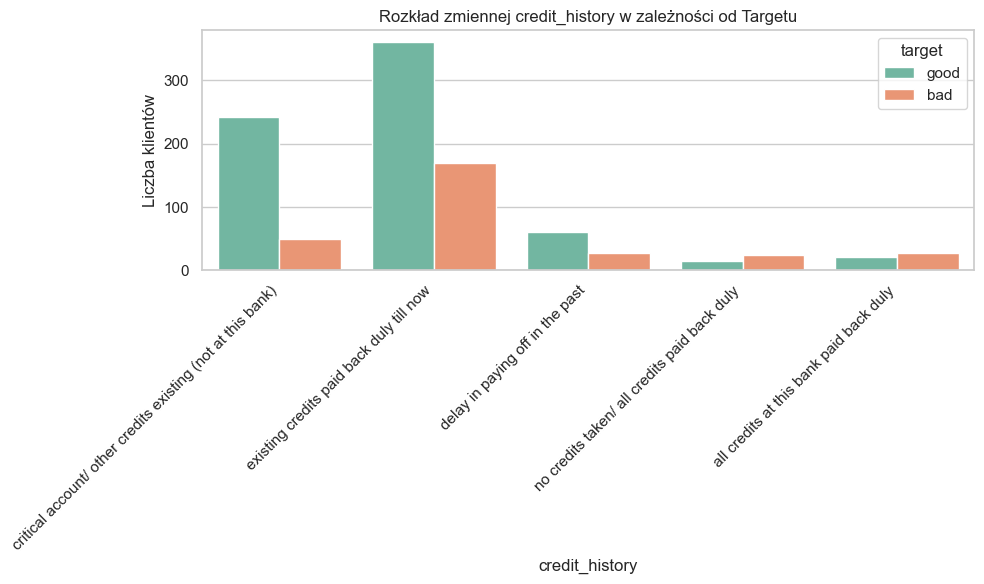

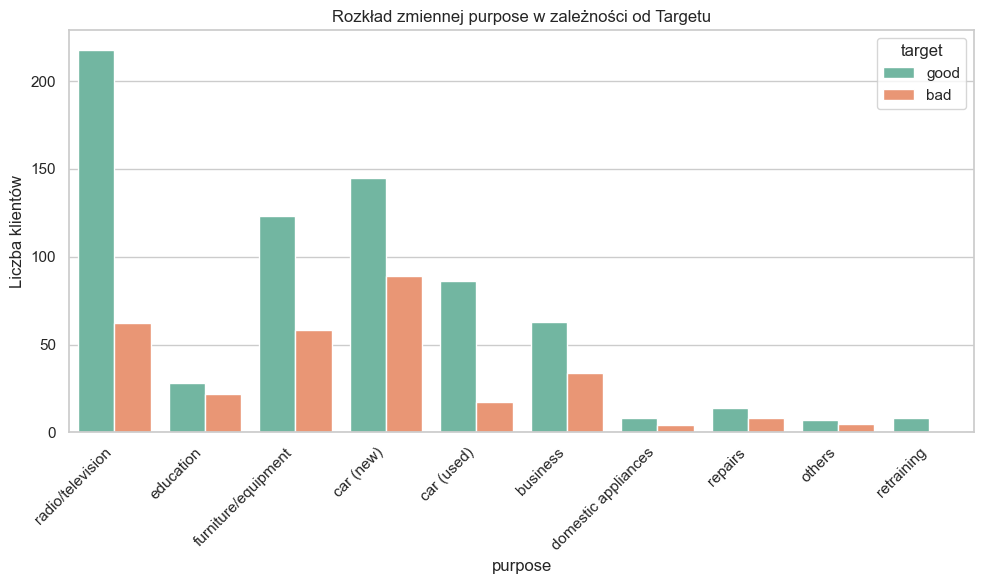

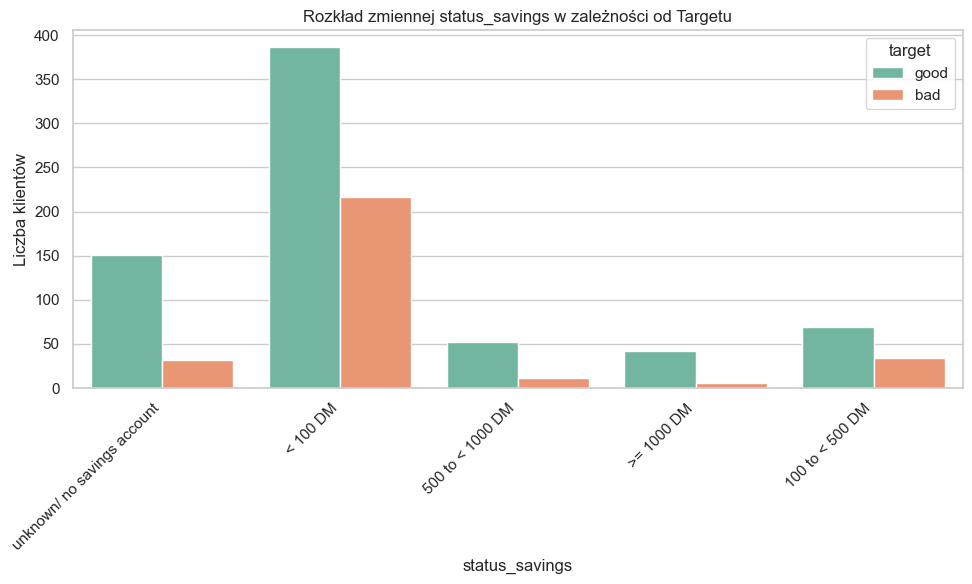

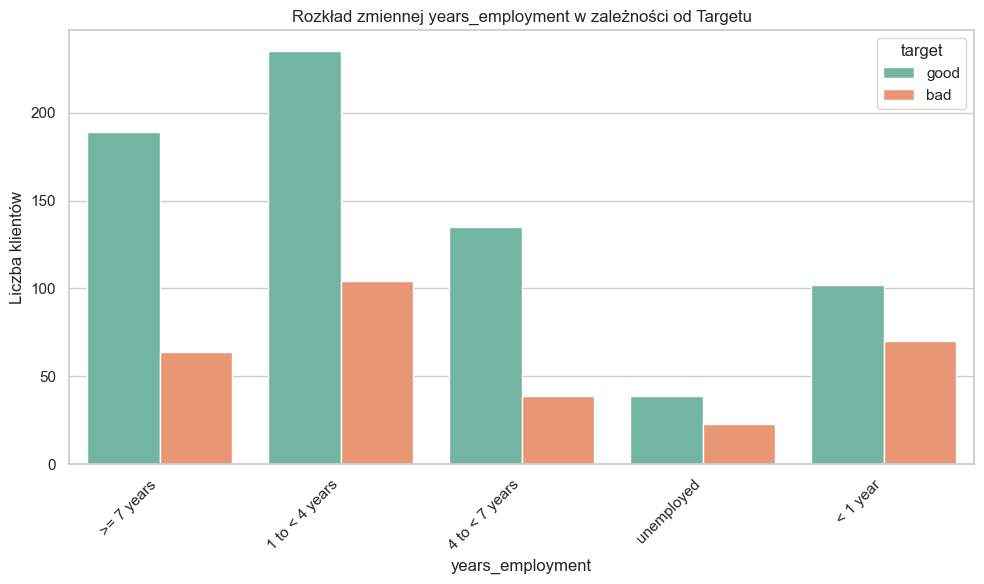

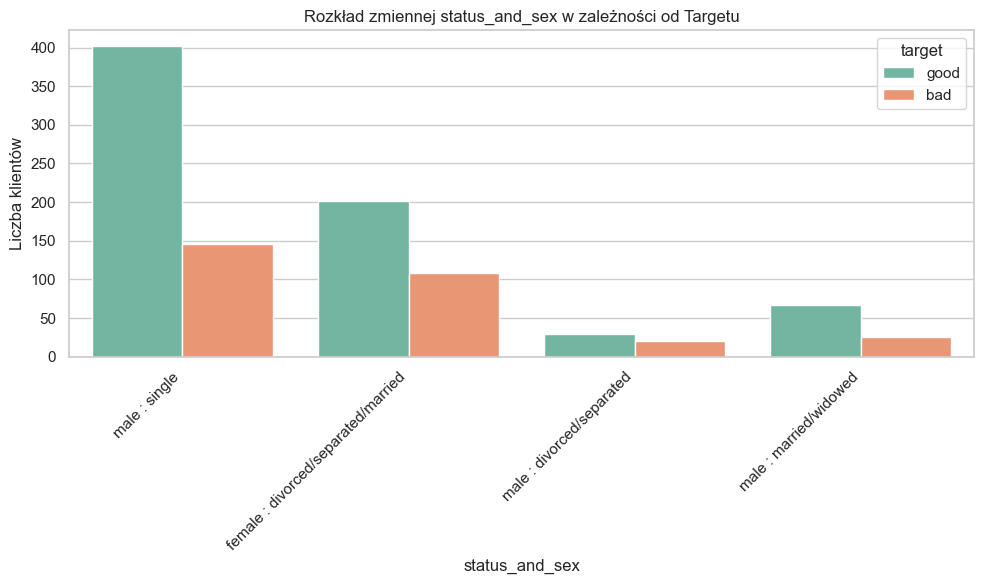

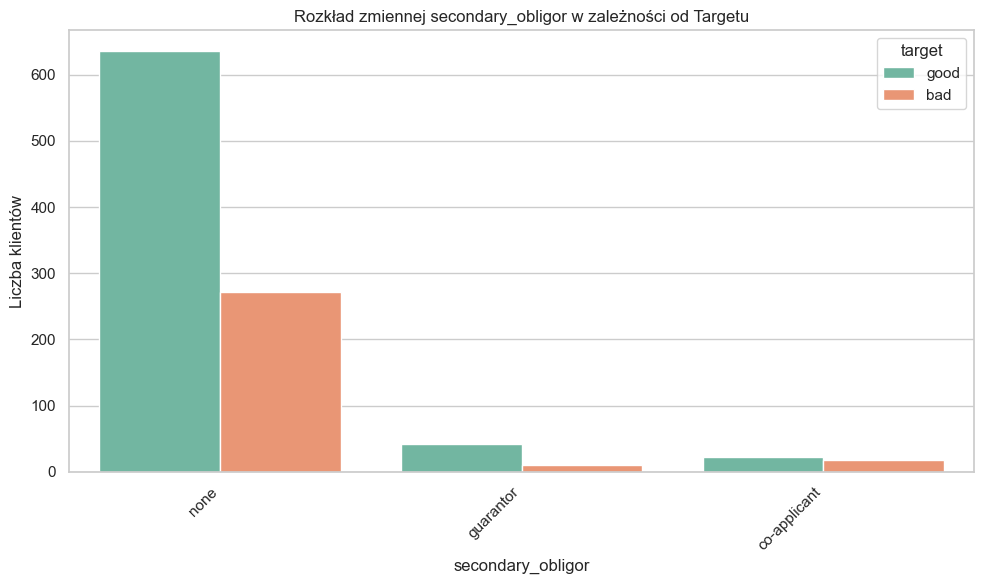

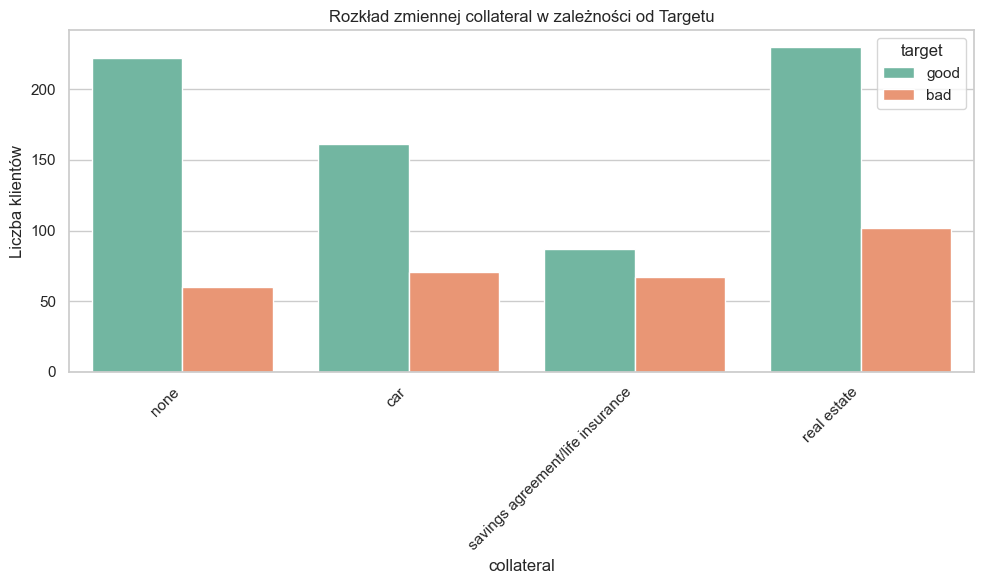

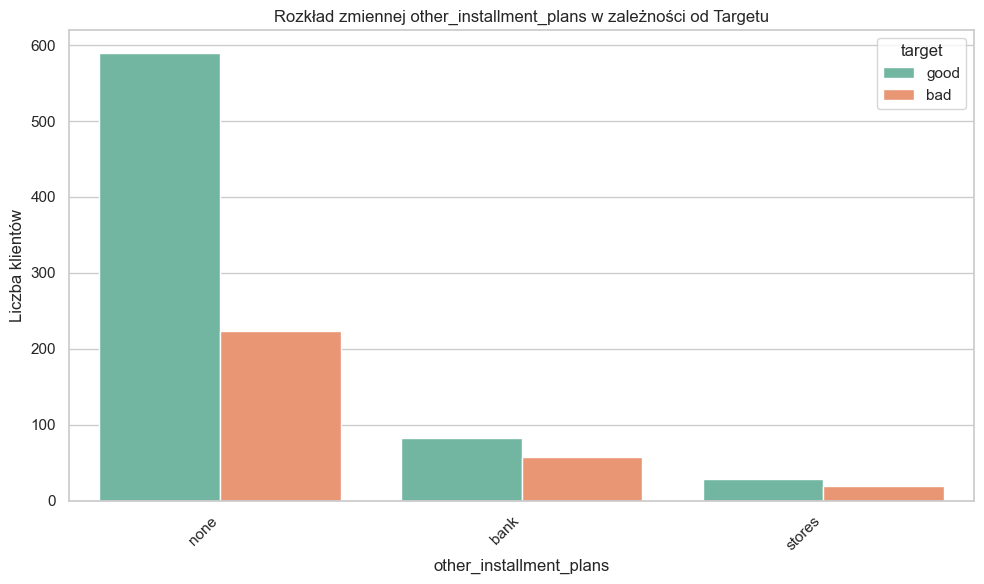

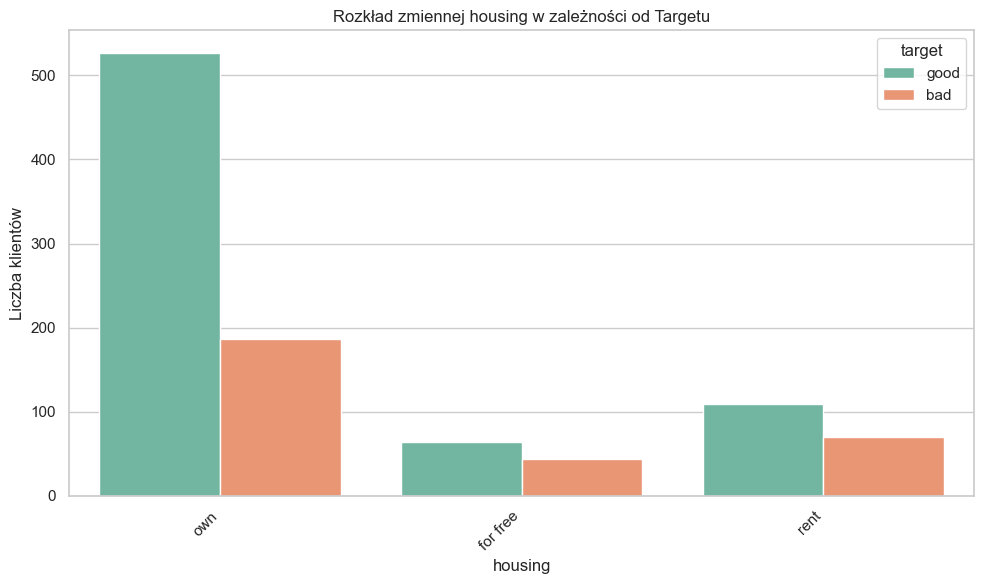

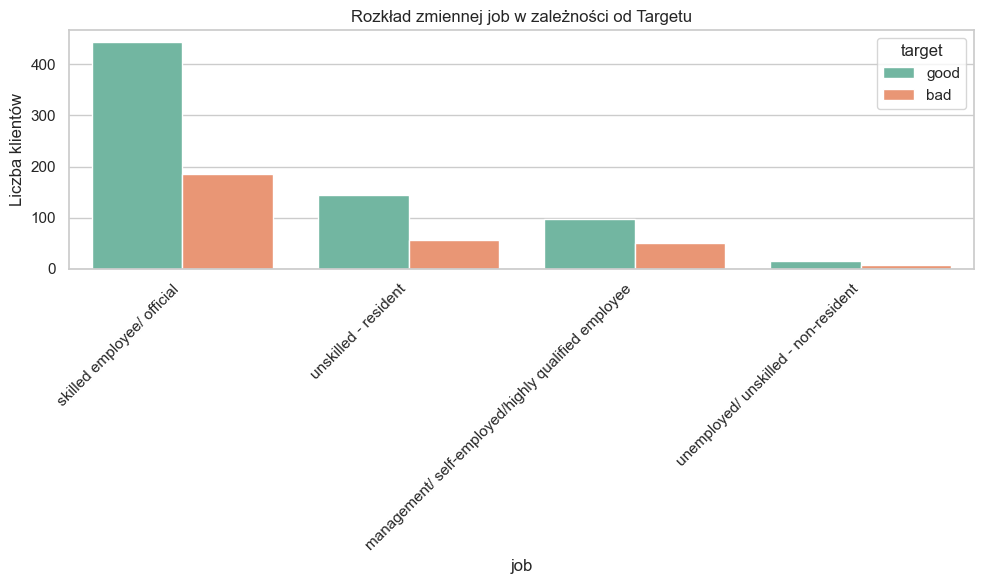

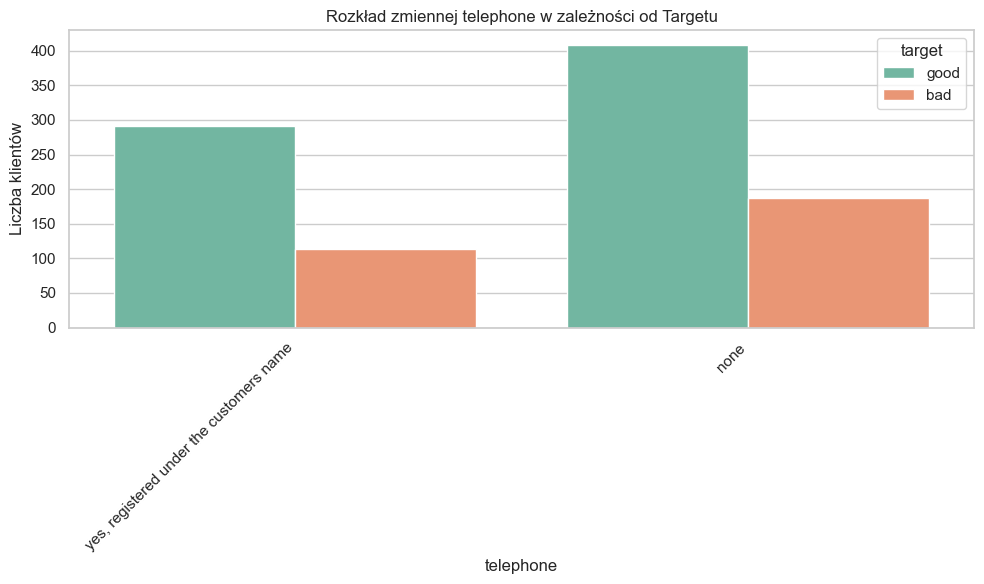

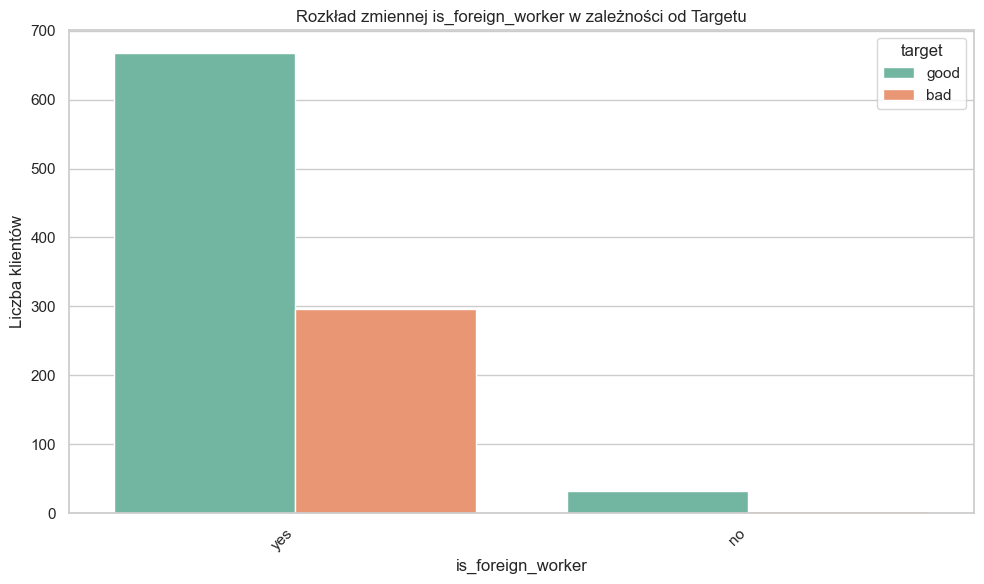

In [67]:
# 1. Wyciągamy nazwy kolumn tekstowych (object)
cat_cols = data.select_dtypes(include=['object']).columns

# 2. Pętla rysująca wykres dla każdej kolumny (pomijamy sam target)
for col in cat_cols:
    if col != 'target':
        sns.countplot(data=data, x=col, hue='target', palette='Set2')
        plt.title(f'Rozkład zmiennej {col} w zależności od Targetu')
        plt.xlabel(col)
        plt.ylabel('Liczba klientów')
        plt.xticks(rotation=45, ha='right') # Obrócenie długich napisów żeby się nie nakładały
        plt.tight_layout()
        plt.show()

In [ ]:
# Analiza zmiennej docelowej
target_counts = data['target'].value_counts()
target_pct = data['target'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Ilość':target_counts, 'Procent':target_pct}))

# Wykres słupkowy
sns.countplot(data=data, x='target', hue='target', legend=False, palette='Set2');

        Ilość  Procent
target                
good      700     70.0
bad       300     30.0


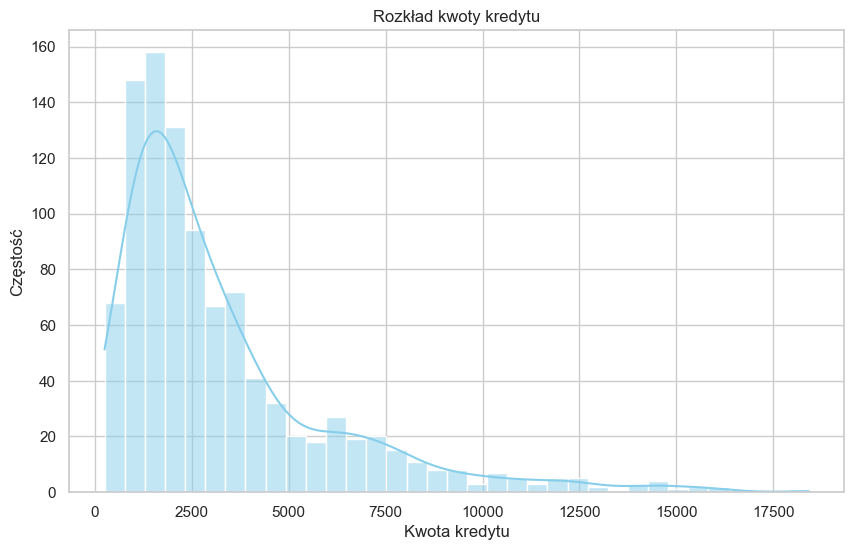

In [7]:
# Wykres 1: Rozkład kwoty kredytu (Histogram)
sns.histplot(data=data, x='credit_amount', kde=True, color='skyblue')
plt.title("Rozkład kwoty kredytu")
plt.xlabel('Kwota kredytu')
plt.ylabel('Częstość')
plt.show();

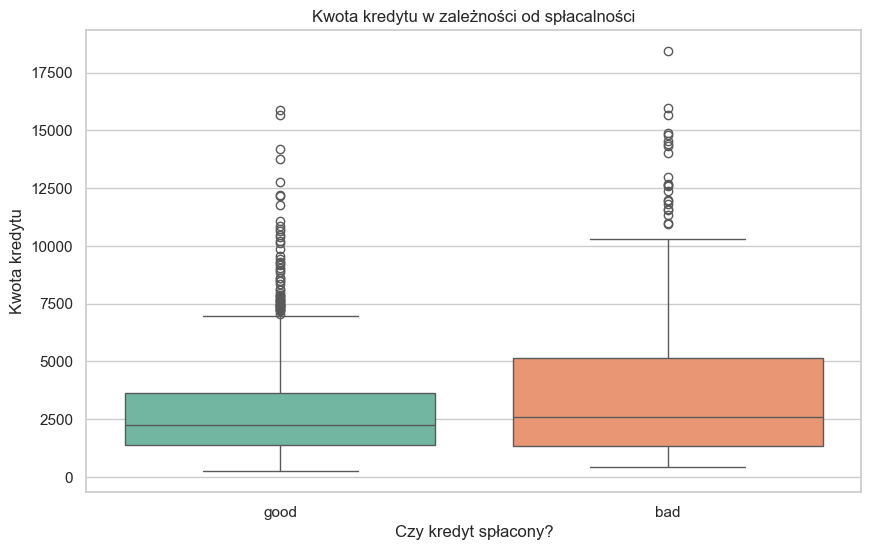

In [8]:
# Wykres 2: Kwota kredytu vs Target (Boxplot)
sns.boxplot(data=data, x='target', y='credit_amount', palette='Set2', hue='target', legend=False)
plt.title("Kwota kredytu w zależności od spłacalności")
plt.xlabel("Czy kredyt spłacony?")
plt.ylabel("Kwota kredytu")
plt.show();

In [9]:
# Badanie Zależności i Korelacji (Heatmap)
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns # słowo Columns jest niezbędne bo potrzebuję tylko nazw kolumn
corr_matrix = data[numerical_cols].corr()
corr_matrix

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
month_duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142
payment_to_income_ratio,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201
n_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667
n_guarantors,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000


In [10]:
numerical_cols = data.select_dtypes(include=['int64', 'float64'])

numerical_cols

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
0,6,1169,4,4,67,2,1
1,48,5951,2,2,22,1,1
2,12,2096,2,3,49,1,2
3,42,7882,2,4,45,1,2
4,24,4870,3,4,53,2,2
5,36,9055,2,4,35,1,2
6,24,2835,3,4,53,1,1
7,36,6948,2,2,35,1,1
8,12,3059,2,4,61,1,1
9,30,5234,4,2,28,2,1
